In [ ]:
# RUN THIS CELL FIRST
import os
import math
from collections import OrderedDict, Counter

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Subset, WeightedRandomSampler
from torchvision import datasets, transforms
from torchvision.transforms import v2

import numpy as np
from numpy import allclose, isclose

from collections.abc import Callable
from sklearn.model_selection import train_test_split

TRAIN_PATH = "data/train"
VAL_PATH = "data/val"
TEST_PATH = "data/test"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
transformations = transforms.Compose(
    [
        v2.Resize((128,128)),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.RandomHorizontalFlip(),
        v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        v2.RandomErasing(p=0.5, scale=(0.1, 0.3)),
        v2.RandomCrop((112,112)),
        v2.RandomAdjustSharpness(2),
        v2.Normalize(mean=[0.5, 0.5, 0.5],
                                 std=[0.5, 0.5, 0.5])
    ]
)

val_transformation = transforms.Compose(
    [
        v2.Resize((128,128)),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.CenterCrop((112, 112)),
        v2.Normalize(mean=[0.5, 0.5, 0.5],
                                 std=[0.5, 0.5, 0.5])
    ]
)

train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=transformations)
val_dataset = datasets.ImageFolder(VAL_PATH, transform=val_transformation)
test_dataset = datasets.ImageFolder(TEST_PATH, transform=val_transformation)

class_labels = list(train_dataset.class_to_idx.keys())
indices = list(range(len(train_dataset)))
labels = [y for _, y in train_dataset]
class_counts = Counter(labels)
weights = [1 / class_counts[i] for i in labels]
num_classes = torch.unique(torch.tensor(labels))

cuda


In [10]:
print(class_counts)
print(train_dataset.class_to_idx)

Counter({7: 1680, 2: 1313, 5: 1313, 6: 1313, 11: 1313, 0: 1156, 3: 1156, 8: 1156, 10: 1156, 1: 999, 12: 999, 4: 19, 9: 19, 13: 19})
{'boots': 0, 'box': 1, 'coin': 2, 'exit': 3, 'floor': 4, 'gem': 5, 'ghost': 6, 'human': 7, 'key': 8, 'lava': 9, 'locked': 10, 'opened': 11, 'shield': 12, 'wall': 13}


In [11]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=8)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

In [12]:
print(len(weights))


13611


In [13]:
def get_accuracy(scores: torch.Tensor, labels: torch.Tensor) -> int | float:
    _, predictions = torch.max(scores, 1)
    # Per-class accuracy breakdown
    classes = torch.unique(labels)
    for cls in classes:
        mask = labels == cls
        cls_acc = (predictions[mask] == labels[mask]).float().mean().item()
        print(f"Class {class_labels[cls.item()]}: {cls_acc:.2%}")
    
    overall = (predictions == labels).float().mean().item()
    print(f"Overall: {overall:.2%}")
    return overall

In [42]:
class TestCNN(nn.Module):
    def __init__(self, classes: int):
        super().__init__()
        self.conv = nn.Sequential(
                        nn.Conv2d(3, 32, (3,3), padding=1, stride=2),
                        nn.BatchNorm2d(32),
                        nn.LeakyReLU(0.1),
                        nn.Dropout(0.5),
                        nn.Conv2d(32, 32, (3,3), padding=1, stride=2),
                        nn.BatchNorm2d(32),
                        nn.LeakyReLU(0.1),
                        nn.Dropout(0.5),
                        nn.Conv2d(32, 64, (3,3), padding=1, stride=2),
                        nn.BatchNorm2d(64),
                        nn.LeakyReLU(0.1),
                        nn.Dropout(0.5),
                        nn.Conv2d(64, 128, (3,3), padding=1, stride=2),
                        nn.BatchNorm2d(128),
                        nn.LeakyReLU(0.1),
                        nn.Dropout(0.5),
                        nn.Conv2d(128, 128, (3,3), padding=1, stride=2),
                        nn.LeakyReLU(0.1),
                    )

        self.fc = nn.Sequential(
                    nn.Dropout(0.5),
                    nn.Linear(128, 64),
                    nn.LeakyReLU(0.1),
                    nn.Dropout(0.5),
                    nn.Linear(64, classes),
                )
        self.gap = nn.AdaptiveAvgPool2d(1)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """ YOUR CODE HERE """
        x = self.conv(x)
        """ YOUR CODE END HERE """
        x = self.gap(x) # GAP – do not remove this line
        """ YOUR CODE HERE """
        x = x.view(x.shape[0], -1)
        out = self.fc(x)
        """ YOUR CODE END HERE """
        return out
    
    def predict_proba(self, x: torch.Tensor) -> torch.Tensor:
        out = self.forward(x)
        return torch.softmax(out, dim = 1)

In [43]:
test_model = TestCNN(14).to(device)
optimiser = torch.optim.SGD(test_model.parameters(), momentum=0.9, lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimiser, 
                mode='min', 
                factor=0.1, 
                patience=10, 
)
min_valloss = math.inf


In [44]:
def train_model(model: nn.Module, dataloader: DataLoader, epochs: int = 20):
    """
    Trains the model for a specified number of epochs/iterations
    
    Parameters
    ---------- 
        model: A PyTorch model to be trained
        dataloader : A DataLoader object that provides batches of the training data
        epochs  : Number of epochs, default of 20
        
    Returns
    -------
        The final model and the loss curve (per epoch)
    """
    global min_valloss, optimiser, scheduler
    losses = []
    total = sum(class_counts.values())
    class_weights = torch.tensor(
        [total / class_counts[i] for i in class_counts.keys()],
        dtype=torch.float32
    ).to(device)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)
    # Set model to training mode. 
    # See (https://stackoverflow.com/questions/60018578/what-does-model-eval-do-in-pytorch) if curious.
    model.train() 
   
    # optimiser = torch.optim.AdamW(model.parameters())
    for i in range(epochs):
        epoch_loss = 0.0
        y_train_out = []
        y_label_out = []
        num_batches = 0
        for x_batch, y_batch in dataloader:
            optimiser.zero_grad()
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            y_output = model(x_batch)
            loss = loss_fn(y_output, y_batch)
            y_train_out += y_output.tolist()
            y_label_out += y_batch.tolist()
            loss.backward()
            optimiser.step()
            epoch_loss += loss.item()
            num_batches += 1
        epoch_loss /= num_batches
        # get_accuracy(torch.tensor(y_train_out), torch.tensor(y_label_out))
        print(f"Epoch {i+1}/{epochs}, Loss: {epoch_loss:.4f}")
        losses.append(epoch_loss)
        num_batches = 0
        model.eval()
        with torch.no_grad():
            val_loss = 0
            y_total_output = []
            y_total = []
            for i, data in enumerate(test_loader):
                x, y = data
                x, y = x.to(device), y.to(device)
                y_output = model(x)
                y_total_output += y_output.tolist()
                y_total += y.tolist()
                val_loss += loss_fn(y_output, y).item()
                num_batches += 1
            get_accuracy(torch.tensor(y_total_output), torch.tensor(y_total))
        val_loss /= num_batches
        print(f"Val Loss: {val_loss:.4f}")
        scheduler.step(val_loss)
        model.train()
        if val_loss < min_valloss:
            min_valloss = val_loss
            torch.save(test_model.state_dict(), "model_weights_med.pth")
        
        

    return model, losses

In [45]:
test_model, test_losses = train_model(test_model, train_loader, epochs = 100)

Epoch 1/100, Loss: 2.6322
Class boots: 13.77%
Class box: 0.00%
Class coin: 0.00%
Class exit: 97.98%
Class floor: 0.00%
Class gem: 0.00%
Class ghost: 66.55%
Class human: 0.00%
Class key: 0.00%
Class lava: 0.00%
Class locked: 0.00%
Class opened: 0.00%
Class shield: 0.00%
Class wall: 0.00%
Overall: 15.93%
Val Loss: 2.6218
Epoch 2/100, Loss: 2.5775
Class boots: 100.00%
Class box: 0.00%
Class coin: 0.00%
Class exit: 2.02%
Class floor: 0.00%
Class gem: 0.00%
Class ghost: 100.00%
Class human: 0.00%
Class key: 0.00%
Class lava: 0.00%
Class locked: 0.00%
Class opened: 0.00%
Class shield: 0.00%
Class wall: 0.00%
Overall: 18.34%
Val Loss: 2.4774
Epoch 3/100, Loss: 2.4535
Class boots: 100.00%
Class box: 0.00%
Class coin: 0.00%
Class exit: 0.00%
Class floor: 0.00%
Class gem: 13.52%
Class ghost: 100.00%
Class human: 0.00%
Class key: 0.00%
Class lava: 0.00%
Class locked: 0.00%
Class opened: 0.00%
Class shield: 5.16%
Class wall: 0.00%
Overall: 19.85%
Val Loss: 2.3591
Epoch 4/100, Loss: 2.3927
Class bo

In [ ]:
test_model_2, test_losses_2 = train_model(TestCNN(14).to(device), train_loader, epochs = 50)

In [ ]:
test_losses_old = test_losses[0:86]

In [48]:
min_valloss

0.1135729561438379

In [69]:
test_model, test_losses2 = train_model(test_model, train_loader, epochs = 50)
test_losses += test_losses2

Epoch 1/50, Loss: 0.4421
Class boots: 97.57%
Class box: 100.00%
Class coin: 100.00%
Class exit: 100.00%
Class floor: 100.00%
Class gem: 75.09%
Class ghost: 100.00%
Class human: 96.39%
Class key: 94.33%
Class lava: 100.00%
Class locked: 100.00%
Class opened: 100.00%
Class shield: 100.00%
Class wall: 66.67%
Overall: 96.42%
Val Loss: 0.0928
Epoch 2/50, Loss: 0.4326
Class boots: 97.98%
Class box: 100.00%
Class coin: 100.00%
Class exit: 100.00%
Class floor: 100.00%
Class gem: 74.73%
Class ghost: 100.00%
Class human: 96.94%
Class key: 94.74%
Class lava: 100.00%
Class locked: 100.00%
Class opened: 100.00%
Class shield: 100.00%
Class wall: 66.67%
Overall: 96.53%
Val Loss: 0.0905
Epoch 3/50, Loss: 0.4119
Class boots: 97.98%
Class box: 100.00%
Class coin: 100.00%
Class exit: 100.00%
Class floor: 100.00%
Class gem: 76.16%
Class ghost: 100.00%
Class human: 95.83%
Class key: 94.74%
Class lava: 100.00%
Class locked: 100.00%
Class opened: 100.00%
Class shield: 100.00%
Class wall: 66.67%
Overall: 96.5

In [12]:
test_losses += test_losses2

In [ ]:
test_model_2, test_losses2 = train_model(test_model_2, train_loader, epochs = 20)
test_losses_2 += test_losses2

In [ ]:
test_model_3, test_losses2 = train_model(test_model_3, train_loader, epochs = 1)
test_losses += test_losses2

In [ ]:
torch.save(test_model.state_dict(), "model_weights.pth")

In [ ]:
torch.save(test_model_2.state_dict(), "model_weights2.pth")

In [ ]:
torch.save(test_model_3.state_dict(), "model_weights3.pth")

In [ ]:
test_losses.pop()

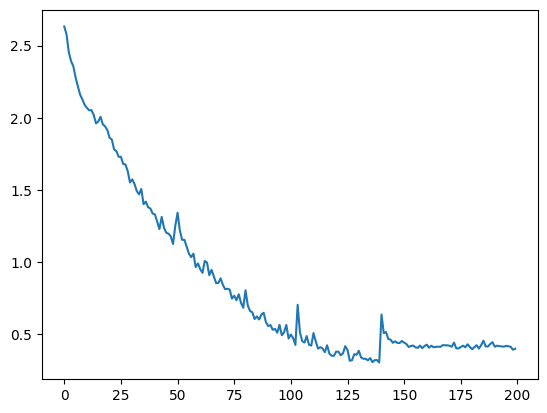

In [70]:
plt.plot(test_losses)

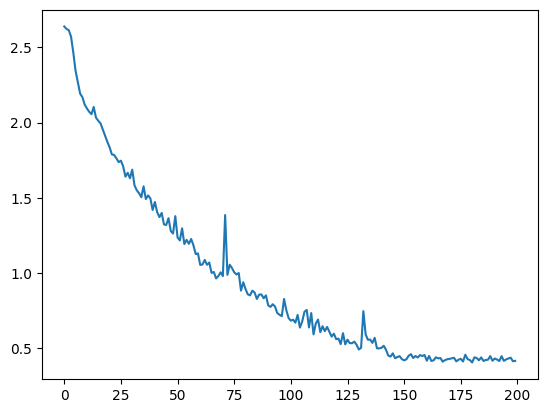

In [22]:
plt.plot(test_losses)

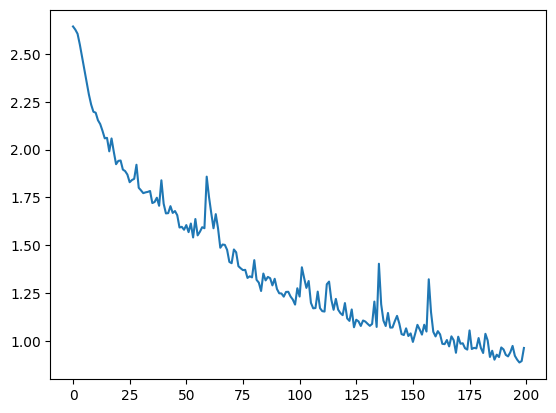

In [15]:
plt.plot(test_losses)

In [71]:
saved_model = torch.load("model_weights_med.pth", weights_only=True)
run_model = TestCNN(14).to(device)
run_model.load_state_dict(saved_model)


<All keys matched successfully>

Class boots: 99.60%
Class box: 100.00%
Class coin: 100.00%
Class exit: 100.00%
Class floor: 100.00%
Class gem: 87.54%
Class ghost: 100.00%
Class human: 95.83%
Class key: 98.38%
Class lava: 100.00%
Class locked: 100.00%
Class opened: 100.00%
Class shield: 98.12%
Class wall: 100.00%
Overall: 97.97%
test accuracy: 0.9797041416168213


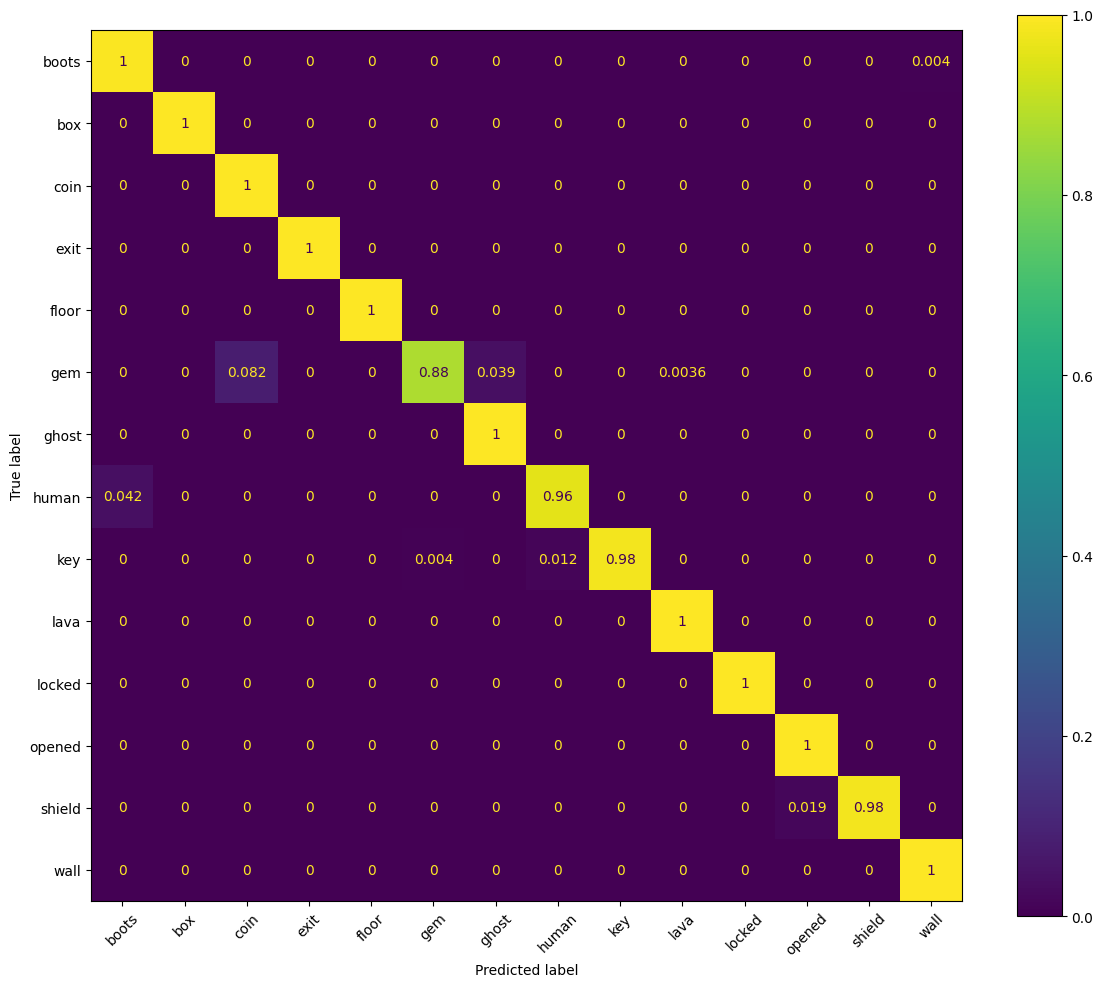

In [72]:
with torch.no_grad():
    run_model.eval()
    y_total = []
    y_output = []
    for i, data in enumerate(val_loader):
        x, y = data
        x, y = x.to(device), y.to(device)
        pred = run_model.predict_proba(x)
        y_output += pred.tolist()
        y_total += y.tolist()
    acc = get_accuracy(torch.tensor(y_output), torch.tensor(y_total))
    print(f"test accuracy: {acc}")
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    _, preds = torch.max(torch.tensor(y_output), 1)
    cm = confusion_matrix(y_total, preds.numpy(), normalize='true')
    disp = ConfusionMatrixDisplay(cm, display_labels=class_labels)
    fig, ax = plt.subplots(figsize=(12, 10))
    disp.plot(ax=ax, xticks_rotation=45)
    plt.tight_layout()
    plt.show()

In [73]:
min_valloss

0.047911887775863644

In [ ]:
from collections import Counter
labels = [label for _, label in train_set]
print(Counter(labels))
